# Sesión 13 B

## Modelos de Mezcla Gaussiana (GMM) 

In [1]:
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import os
ruta = os.path.join('..', 'data', 'bank_customer_data.csv')
df = pd.read_csv(ruta)
df.head()

,income,debt,labels
0,2.985433,1.467052,0.0
1,1.661632,6.248713,1.0
2,2.131999,6.693823,1.0
3,5.851889,4.742888,2.0
4,3.404236,2.991008,0.0


In [3]:
df.shape

(400, 3)

In [4]:
df.labels.value_counts()

labels
0.0    200
1.0    150
2.0     50
Name: count, dtype: int64

#### 1. Gaussian Mixture Model (GMM) básico

In [5]:
GaussianMixture?

Init signature:
GaussianMixture(
    n_components=1,
    *,
    covariance_type='full',
    tol=0.001,
    reg_covar=1e-06,
    max_iter=100,
    n_init=1,
    init_params='kmeans',
    weights_init=None,
    means_init=None,
    precisions_init=None,
    random_state=None,
    warm_start=False,
    verbose=0,
    verbose_interval=10,
)
Docstring:     
Gaussian Mixture.

Representation of a Gaussian mixture model probability distribution.
This class allows to estimate the parameters of a Gaussian mixture
distribution.

Read more in the :ref:`User Guide <gmm>`.

.. versionadded:: 0.18

Parameters
----------
n_components : int, default=1
    The number of mixture components.

covariance_type : {'full', 'tied', 'diag', 'spherical'}, default='full'
    String describing the type of covariance parameters to use.
    Must be one of:

    - 'full': each component has its own general covariance matrix.
    - 'tied': all components share the same general covariance matrix.
    - 'diag': each co

* **También puedes checar la documentación oficial de sklearn sobre GMM [aquí](https://scikit-learn.org/stable/modules/mixture.html#gmm).**

In [22]:
# Modelo de mezclas Gaussianas
gmm = GaussianMixture(
    n_components=3
)

In [23]:
# Entrenamos
gmm.fit(df[['income', 'debt']])

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [24]:
# Parámetros óptimos: means_
gmm.means_[0]

array([2.96040004, 2.57742868])

In [25]:
# Parámetros óptimos: covariances_
gmm.covariances_

array([[[ 1.09095334, -0.21668949],
        [-0.21668949,  1.08251907]],

       [[ 0.53573118, -0.10747755],
        [-0.10747755,  0.76187159]],

       [[ 0.948484  ,  0.90614216],
        [ 0.90614216,  1.00900976]]])

In [26]:
# Parámetros óptimos: weights_
gmm.weights_

array([0.49736151, 0.37979719, 0.1228413 ])

In [27]:
from scipy.stats import multivariate_normal

# Gaussianas ajustadas
X1 = multivariate_normal(
    mean=gmm.means_[0],
    cov=gmm.covariances_[0]
)
X2 = multivariate_normal(
    mean=gmm.means_[1],
    cov=gmm.covariances_[1]
)
X3 = multivariate_normal(
    mean=gmm.means_[2],
    cov=gmm.covariances_[2]
)
#X4 = multivariate_normal(
#    mean=gmm.means_[3],
#    cov=gmm.covariances_[3]
#)

In [28]:
# Predicción de probabilidades
probas = gmm.predict_proba(df[['income', 'debt']])
probas

array([[9.97898701e-01, 3.63395861e-06, 2.09766539e-03],
       [1.59470132e-03, 9.98405299e-01, 1.28157116e-49],
       [4.45537550e-04, 9.99554462e-01, 1.41247255e-48],
       ...,
       [9.96186473e-01, 3.81352745e-03, 4.36364940e-11],
       [9.99985299e-01, 2.23920789e-06, 1.24613957e-05],
       [2.87390800e-01, 7.12609200e-01, 4.97269931e-23]], shape=(400, 3))

In [29]:
# Convertir a DataFrame
df_probas = pd.DataFrame(
    probas,
    columns=[f"componente_{i}" for i in range(3)]
)

In [30]:
df_probas

,componente_0,componente_1,componente_2
0,0.997899,0.000004,2.097665e-03
1,0.001595,0.998405,1.281571e-49
2,0.000446,0.999554,1.412473e-48
3,0.000871,0.000003,9.991260e-01
4,0.988526,0.002157,9.317247e-03
...,...,...,...
395,0.977300,0.000057,2.264287e-02
396,0.051108,0.948892,5.911349e-29
397,0.996186,0.003814,4.363649e-11
398,0.999985,0.000002,1.246140e-05


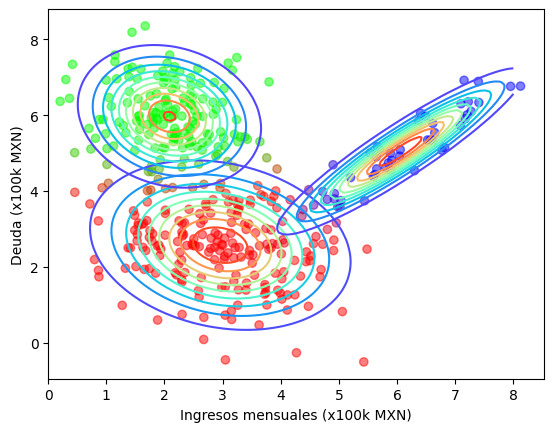

In [31]:
# Datos
plt.scatter(
    x=df['income'],
    y=df['debt'], 
    c=gmm.predict_proba(df[['income', 'debt']]),
    cmap='Accent',
    alpha=0.5
)
# Añadimos etiquetas a los ejes
plt.xlabel('Ingresos mensuales (x100k MXN)')
plt.ylabel('Deuda (x100k MXN)')

# Gaussiana 1
x = np.linspace(0, 8, 100)
y = np.linspace(0, 8, 100)
X, Y = np.meshgrid(x, y)
z = X1.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
plt.contour(X, Y, z, levels=10, cmap='rainbow')

# Gaussiana 2
x = np.linspace(0, 8, 100)
y = np.linspace(0, 8, 100)
X, Y = np.meshgrid(x, y)
z = X2.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
plt.contour(X, Y, z, levels=10, cmap='rainbow')

# Gaussiana 3
x = np.linspace(0, 8, 100)
y = np.linspace(0, 8, 100)
X, Y = np.meshgrid(x, y)
z = X3.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
plt.contour(X, Y, z, levels=10, cmap='rainbow')

# Gaussiana 4
#x = np.linspace(0, 8, 100)
#y = np.linspace(0, 8, 100)
#X, Y = np.meshgrid(x, y)
#z = X4.pdf(np.dstack((X, Y)))
# Graficamos la función de densidad
#plt.contour(X, Y, z, levels=10, cmap='rainbow')

---

#### 2. Probar varios números de componentes y comparar BIC

In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
#BIC
ks = range(1, 10)
bics = []

for k in ks:
    gmm = GaussianMixture(n_components=k)
    gmm.fit(df[['income', 'debt']])
    bics.append(gmm.bic(df[['income', 'debt']]))

list1 = list(zip(ks, bics))
list1

[(1, 3139.7023248527153),
 (2, 3047.3837113363734),
 (3, 2848.5387889567273),
 (4, 2879.9717941906747),
 (5, 2912.9592772354968),
 (6, 2947.9448585524756),
 (7, 2975.622809654209),
 (8, 2993.6405802994573),
 (9, 3027.996693512954)]

In [18]:
min(list1, key=lambda x: x[1])

(3, 2848.5387889567273)

In [19]:
#AIC
aics = []
for k in ks:
    gmm = GaussianMixture(n_components=k)
    gmm.fit(df[['income', 'debt']])
    aics.append(gmm.aic(df[['income', 'debt']]))

list2 = list(zip(ks, aics))
list2

[(1, 3119.7450021171753),
 (2, 3003.4776013181854),
 (3, 2780.788837891324),
 (4, 2788.173546933373),
 (5, 2797.536655299446),
 (6, 2806.670015857858),
 (7, 2810.5504095967462),
 (8, 2819.6732195739482),
 (9, 2817.055557795682)]

In [20]:
min(list2, key=lambda x: x[1])

(3, 2780.788837891324)

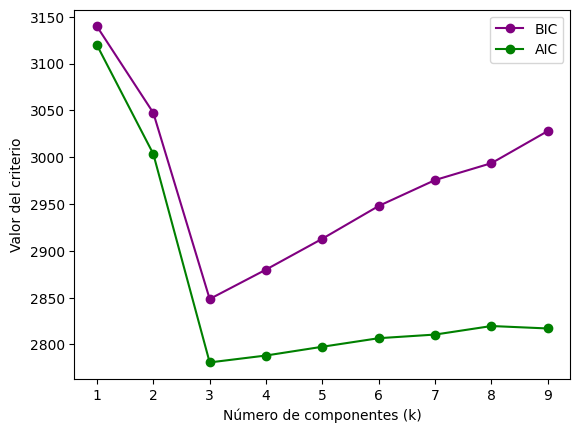

In [21]:
# Mostrar resultados
plt.plot(ks, bics, marker='o', label="BIC", color='purple')
plt.plot(ks, aics, marker='o', label="AIC", color='green')
plt.xlabel("Número de componentes (k)")
plt.ylabel("Valor del criterio")
plt.legend()
plt.show()